In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df= pd.read_csv('/content/drive/MyDrive/only.data/Amazon Sale Repor.csv')
df.head()

<ipython-input-35-4d42ca87e6c3>:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('/content/drive/MyDrive/only.data/Amazon Sale Repor.csv')


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [ ]:
df.shape

(128975, 23)

In [ ]:
df["Sales Channel "].value_counts()

Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64

#objectives
#1. which city and state has more sales
#2. what kind of product sold more in / in different state and city
#3. which city give more percentage of sales

#4. percentage of cencelation rate
#5. which state have made more cencelation
#6. which product was more cenceled
#7. relationship between b2b and cencelation
#8. relationship between sales chennel and cencelation

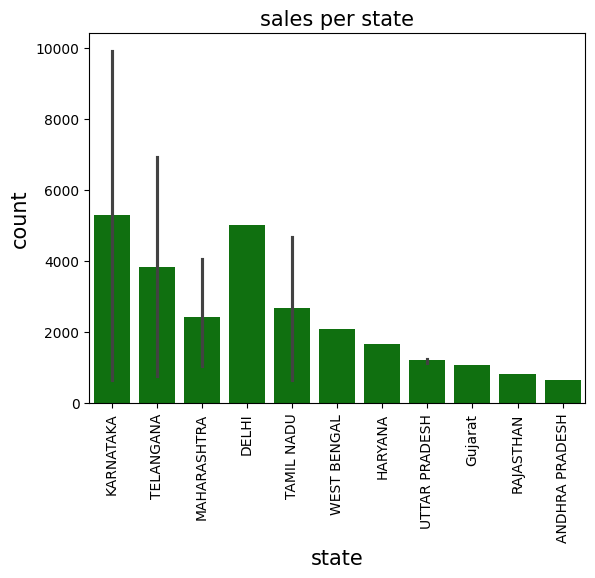

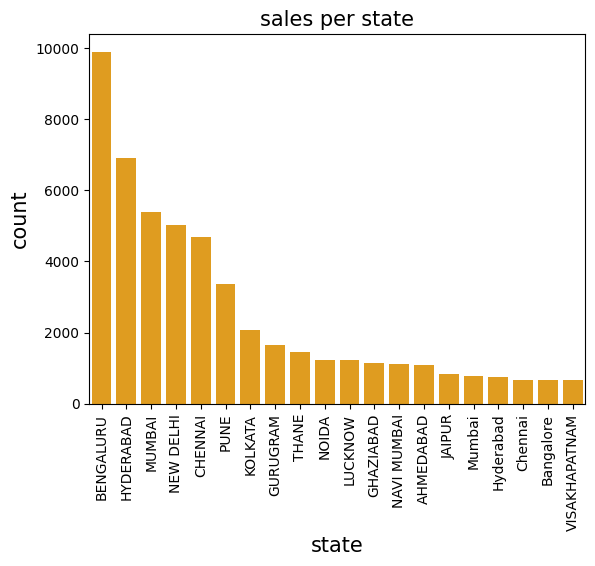

In [ ]:
#1. which city and state has more sales
df["ship-city"].value_counts()
df["ship-state"].str.upper()
dff=df[df["Status"] != "Cancelled"]#dont add cenelation one
dff["ship-city"].str.capitalize()
dff["ship-state"].str.capitalize()
df_f=pd.DataFrame(dff[["ship-state","ship-city"]].value_counts().nlargest(20))
sns.barplot(x="ship-state",y="count",data=df_f,color="green")
plt.xticks(rotation=90)
plt.ylabel("count",fontsize=15)
plt.xlabel("state",fontsize=15)
plt.title("sales per state",fontsize=15)
plt.xticks(rotation=90)
plt.show()
sns.barplot(x="ship-city",y="count",data=df_f,color="orange")
plt.xticks(rotation=90)
plt.ylabel("count",fontsize=15)
plt.xlabel("state",fontsize=15)
plt.title("sales per state",fontsize=15)
plt.xticks(rotation=90)
plt.show()

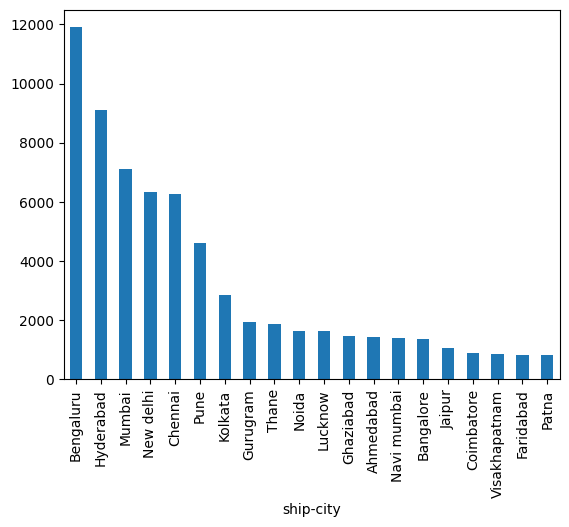

In [ ]:
df["ship-city"].value_counts().head(20)
gy=df["ship-city"].str.capitalize().value_counts().head(20).plot(kind="bar")



what kind of product sold more in / in different state and city

<Axes: xlabel='ship-state,ship-city'>

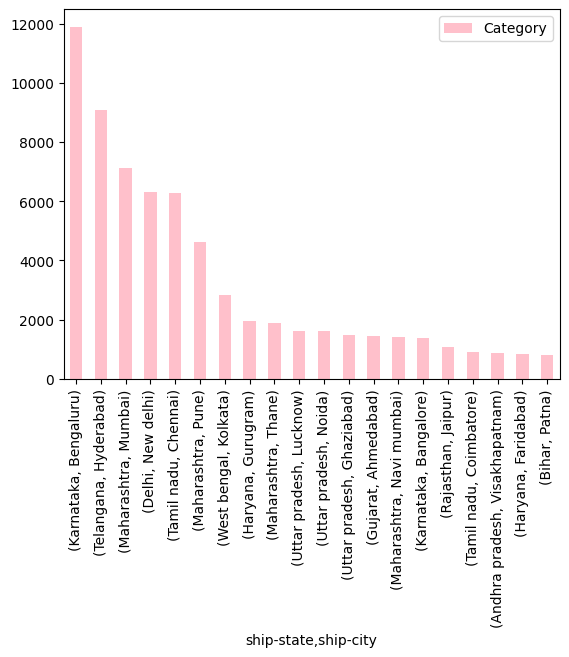

In [ ]:
#what kind of product sold more in / in different state and city
df["ship-city"]=df["ship-city"].str.capitalize()
df["ship-state"]=df["ship-state"].str.capitalize()
dd=df.groupby(["ship-state","ship-city"]).agg({"Category":"count"})
dd.nlargest(20,"Category").plot(kind="bar",color="pink")

In [ ]:
df.groupby(["ship-state"]).agg({"ship-city":"count"}).nlargest(20,"ship-city")


,,ship-city
ship-state,ship-city,
Karnataka,Bengaluru,11898
Telangana,Hyderabad,9092
Maharashtra,Mumbai,7122
Delhi,New delhi,6311
Tamil nadu,Chennai,6284
Maharashtra,Pune,4617
West bengal,Kolkata,2844
Haryana,Gurugram,1954
Maharashtra,Thane,1877


In [21]:
df["ship-city"].value_counts().head(15)

ship-city
BENGALURU      11217
HYDERABAD       8074
MUMBAI          6126
NEW DELHI       5795
CHENNAI         5421
PUNE            3857
KOLKATA         2381
GURUGRAM        1868
THANE           1701
LUCKNOW         1458
NOIDA           1419
GHAZIABAD       1328
NAVI MUMBAI     1263
AHMEDABAD       1236
JAIPUR           948
Name: count, dtype: int64

In [ ]:
df[""]

how to prob perticular value in  cxolumes

In [23]:
#how to drop perrticulare value in the colume
Ndf=pd.DataFrame(df[df["ship-city"].isin(["BENGALURU","HYDERABAD","MUMBAI ","NEW DELHI","CHENNAI","PUNE","KOLKATA","GURUGRAM","THANE","LUCKNOW","NOIDA","GHAZIABAD","NAVI MUMBAI","AHMEDABAD","JAIPUR"])])
Ndf

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
1,171-9198151-1101146,04-30-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.0,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
4,407-1069790-7240320,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,404-1490984-4578765,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,XL,...,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
7,406-7807733-3785945,04-30-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,S,...,INR,399.0,HYDERABAD,TELANGANA,500032.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128956,403-0816822-3188305,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,NW032,NW032-ST-CP-XXXL,Set,3XL,...,INR,992.0,CHENNAI,TAMIL NADU,600042.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128959,403-9813694-4657102,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3781,JNE3781-KR-M,kurta,M,...,INR,432.0,NEW DELHI,DELHI,110043.0,IN,NaN,False,NaN,False
128970,406-6001380-7673107,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,...,INR,517.0,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128971,402-9551604-7544318,04-30-2022,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,M,...,INR,999.0,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


Status
Shipped                          60.324869
Shipped - Delivered to Buyer     22.305873
Cancelled                        14.213607
Shipped - Returned to Seller      1.514247
Shipped - Picked Up               0.754410
Pending                           0.510176
Pending - Waiting for Pick Up     0.217872
Shipped - Returning to Seller     0.112425
Shipped - Out for Delivery        0.027137
Shipped - Rejected by Buyer       0.008529
Shipping                          0.006203
Shipped - Lost in Transit         0.003877
Shipped - Damaged                 0.000775
Name: proportion, dtype: float64


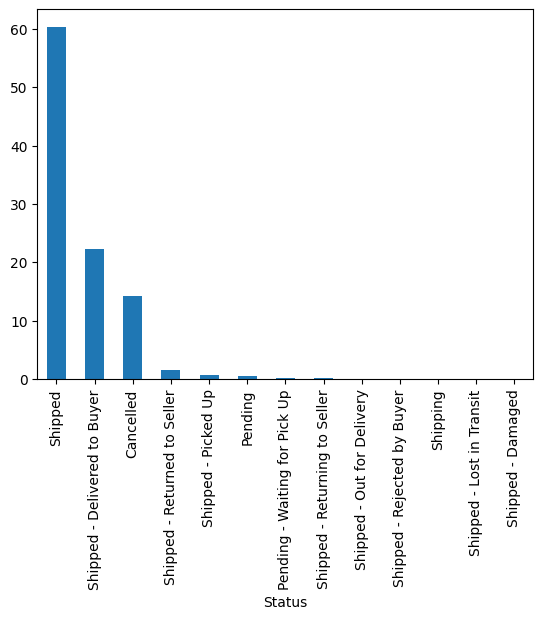

In [34]:
#why the cencellation rate in percentage
gg=df["Status"].value_counts(normalize=True)*100
gg.plot(kind="bar")
print(gg)

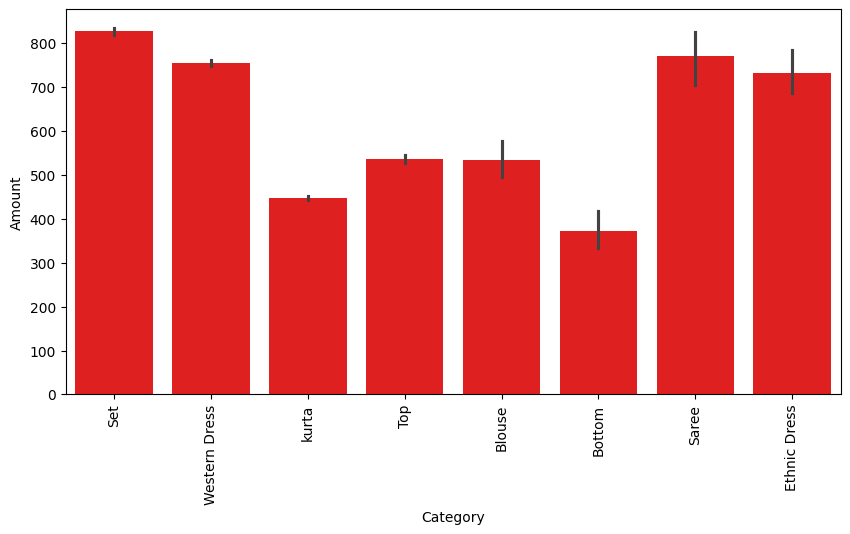

<Axes: xlabel='Category', ylabel='count'>

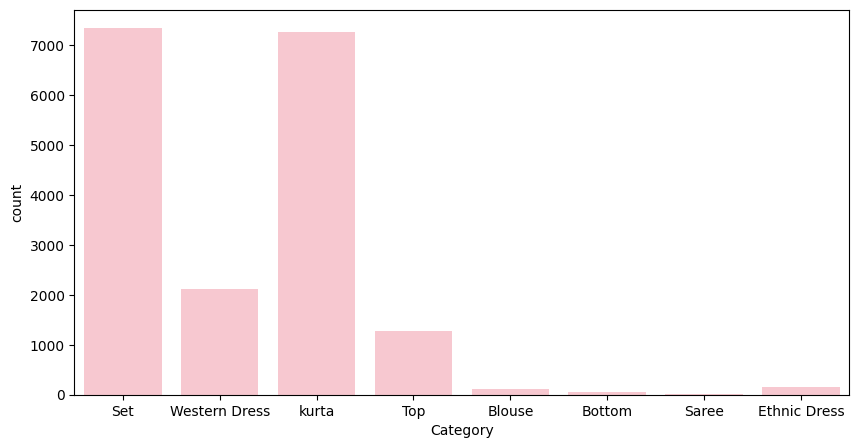

In [45]:
kk=df[df["Status"]=="Cancelled"]
plt.figure(figsize=(10,5))
sns.barplot(x="Category",y="Amount",data=kk,color="red")
plt.xticks(rotation=90)
plt.show()
plt.figure(figsize=(10,5))
sns.countplot(x="Category",data=kk,color="pink")


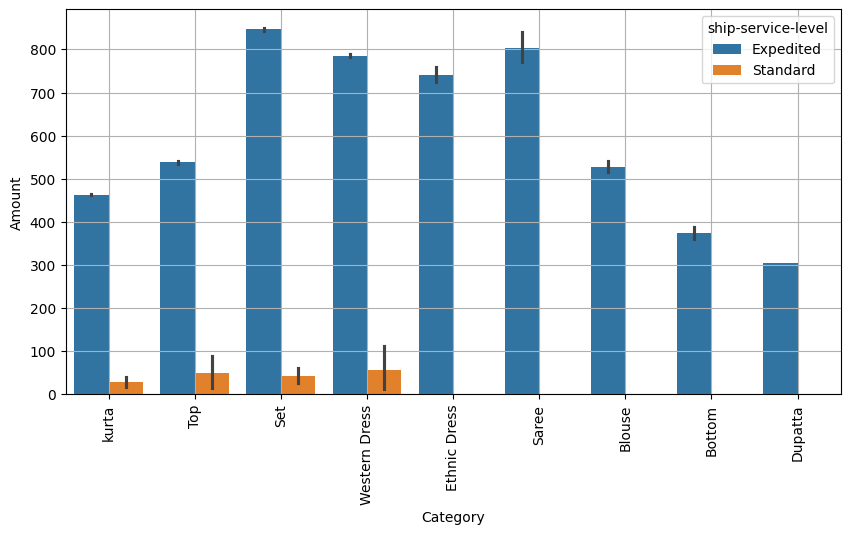

In [50]:
kk=df[df["Status"]=="Shipped"]
plt.figure(figsize=(10,5))
sns.barplot(x="Category",y="Amount",data=kk,hue="ship-service-level")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


In [51]:
kk["ship-service-level"].value_counts()

ship-service-level
Expedited    76779
Standard      1025
Name: count, dtype: int64